In [98]:
import os
from typing import TypedDict, Annotated, List, Dict
import gradio as gr
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from IPython.display import Image, display
import fitz
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage


In [99]:
class State(TypedDict):
    """
    The state for our LangGraph agent.
    """
    # documents: List[str] # List of document identifiers
    chat_history: List[Dict[str, str]]
    query: str
    response: str
    document: Dict[str, str]
    extracted_text: Dict[str, str]
    summary: str
    question_list: List[str]
    s3Uri: Dict[str, str]
    bda_result: Dict[str, str]
    messages: Annotated[list, add_messages]
    # is_inter_document_query: bool

In [100]:
load_dotenv(override=True)

GEMINI_BASE_URL = os.getenv("GEMINI_BASE_URL")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
llm = init_chat_model("google_genai:gemini-2.5-flash")

In [101]:
import base64
import fitz  # PyMuPDF
import boto3
from io import BytesIO
import logging
from urllib.parse import urlparse
from langchain_core.tools import tool
import json
import uuid

logger = logging.getLogger()
logger.setLevel(logging.INFO)

@tool
def extract_image_from_pdf_bbox(inputs: dict, state: dict):
    """
    Tool to crop an image from a PDF stored in S3 using bounding box details
    and upload the cropped image back to S3.

    Args:
        inputs (dict): {
            "filename": str,
            "geometry": {
                "boundingBox": {
                    "left": float,
                    "top": float,
                    "width": float,
                    "height": float
                },
                "page": int
            },
            "outputS3Bucket": str  # Optional: target bucket to store cropped image
        }
        state (dict): {
            "s3Uri": {
                "<filename>": "<s3_uri>"
            }
        }

    Returns:
        dict: {
            "image_base64": base64 encoded PNG of the cropped region,
            "s3Uri": "<uploaded_image_s3_uri>"
        }
    """
    try:
        if isinstance(inputs, str):
            try:
                inputs = json.loads(inputs)
            except Exception as e:
                return {"error": f"Failed to parse inputs JSON: {str(e)}"}

        filename = inputs.get("filename")
        geometry = inputs.get("geometry")
        output_bucket = inputs.get("outputS3Bucket", "")  # optional

        if not filename or not geometry:
            return {"error": "Missing filename or geometry"}

        bbox = geometry.get("boundingBox")
        if not bbox:
            return {"error": "Missing boundingBox in geometry"}

        # Lookup S3 URI from state
        s3_uri = state.get("s3Uri", {}).get(filename)
        if not s3_uri:
            return {"error": f"No S3 URI found for '{filename}'"}

        parsed = urlparse(s3_uri)
        bucket = parsed.netloc
        key = parsed.path.lstrip("/")

        # Download PDF from S3
        s3 = boto3.client("s3")
        obj = s3.get_object(Bucket=bucket, Key=key)
        pdf_bytes = obj["Body"].read()

        # Open PDF with PyMuPDF
        doc = fitz.open(stream=BytesIO(pdf_bytes), filetype="pdf")
        page_num = geometry.get("page", 1) - 1  # 0-indexed
        page_num = int(page_num)
        if page_num >= len(doc):
            return {"error": f"Invalid page number: {page_num + 1}"}

        page = doc.load_page(page_num)
        page_width, page_height = page.rect.width, page.rect.height

        # Normalized bbox -> absolute coordinates
        x0 = bbox["left"] * page_width
        y0 = bbox["top"] * page_height
        x1 = x0 + (bbox["width"] * page_width)
        y1 = y0 + (bbox["height"] * page_height)

        # Apply padding (10%)
        width = x1 - x0
        height = y1 - y0
        padding_x = width * 0.1
        padding_y = height * 0.1

        x0 = max(0, x0 - padding_x)
        y0 = max(0, y0 - padding_y)
        x1 = min(page_width, x1 + padding_x)
        y1 = min(page_height, y1 + padding_y)

        rect = fitz.Rect(x0, y0, x1, y1)
        matrix = fitz.Matrix(2.0, 2.0)  # upscale
        pix = page.get_pixmap(matrix=matrix, clip=rect)
        image_bytes = pix.tobytes("png")

        doc.close()

        # Determine S3 bucket to store cropped image
        if not output_bucket:
            output_bucket = bucket  # default to same bucket as PDF
        image_key = f"cropped_images/{uuid.uuid4().hex}.png"

        # Upload cropped image to S3
        s3.put_object(Bucket=output_bucket, Key=image_key, Body=image_bytes, ContentType="image/png")
        # Construct S3 object URL (not URI)
        s3_url = f"https://{output_bucket}.s3.amazonaws.com/{image_key}"    

        return {
            "success": True,
            # "message": "Cropped image extracted and uploaded successfully.",
            # "image_base64": base64.b64encode(image_bytes).decode("utf-8"),
            "s3Url": s3_url
        }

    except Exception as e:
        logger.error(f"Cropping/upload error: {str(e)}")
        return {"error": str(e)}


In [102]:
# result = extract_image_from_pdf_bbox.invoke({'state': {'s3Uri': {'144255Store Pack.pdf': 's3://document-processing-agent-pratik/uploads/6bc74cf2-4dbb-46e1-8ece-4f8d5121ba45/144255Store Pack.pdf'}}, 'inputs': {'geometry': {'page': 1.0, 'boundingBox': {'height': 0.017244239934959882, 'left': 0.19751502127328932, 'top': 0.43722645437088303, 'width': 0.08726097532846325}}, 'filename': '144255Store Pack.pdf'}})
# print(result)


In [103]:
from langchain_core.tools import Tool

# Register the tool
# image_tool = Tool(
#     name="extract_image_from_bbox",
#     description="Extracts a cropped image from a document in S3 using LLM-supplied bounding box.",
#     func=extract_image_from_bbox
# )
tools = [extract_image_from_pdf_bbox]

# Bind tools to your LLM
llm_with_tools = llm.bind_tools(tools)

In [104]:
extract_image_from_pdf_bbox.args_schema.schema()


C:\Users\PratikTalaviya\AppData\Local\Temp\ipykernel_10920\1859862078.py:1: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  extract_image_from_pdf_bbox.args_schema.schema()


{'description': 'Tool to crop an image from a PDF stored in S3 using bounding box details\nand upload the cropped image back to S3.\n\nArgs:\n    inputs (dict): {\n        "filename": str,\n        "geometry": {\n            "boundingBox": {\n                "left": float,\n                "top": float,\n                "width": float,\n                "height": float\n            },\n            "page": int\n        },\n        "outputS3Bucket": str  # Optional: target bucket to store cropped image\n    }\n    state (dict): {\n        "s3Uri": {\n            "<filename>": "<s3_uri>"\n        }\n    }\n\nReturns:\n    dict: {\n        "image_base64": base64 encoded PNG of the cropped region,\n        "s3Uri": "<uploaded_image_s3_uri>"\n    }',
 'properties': {'inputs': {'additionalProperties': True,
   'title': 'Inputs',
   'type': 'object'},
  'state': {'additionalProperties': True, 'title': 'State', 'type': 'object'}},
 'required': ['inputs', 'state'],
 'title': 'extract_image_from_p

In [105]:
tools

[StructuredTool(name='extract_image_from_pdf_bbox', description='Tool to crop an image from a PDF stored in S3 using bounding box details\nand upload the cropped image back to S3.\n\nArgs:\n    inputs (dict): {\n        "filename": str,\n        "geometry": {\n            "boundingBox": {\n                "left": float,\n                "top": float,\n                "width": float,\n                "height": float\n            },\n            "page": int\n        },\n        "outputS3Bucket": str  # Optional: target bucket to store cropped image\n    }\n    state (dict): {\n        "s3Uri": {\n            "<filename>": "<s3_uri>"\n        }\n    }\n\nReturns:\n    dict: {\n        "image_base64": base64 encoded PNG of the cropped region,\n        "s3Uri": "<uploaded_image_s3_uri>"\n    }', args_schema=<class 'langchain_core.utils.pydantic.extract_image_from_pdf_bbox'>, func=<function extract_image_from_pdf_bbox at 0x00000275156B68E0>)]

In [106]:
from PIL import ImageEnhance, ImageFilter

def preprocess_image(image):
    # Convert to grayscale
    image = image.convert('L')
    # Increase contrast
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(2)
    # Apply sharpening
    image = image.filter(ImageFilter.SHARPEN)
    return image

In [107]:
# import pytesseract
# from pdf2image import convert_from_bytes

# def extract_text_with_ocr(file_bytes):
#     """Extract text from scanned/image-based PDF using Tesseract OCR."""
#     text = ""
#     images = convert_from_bytes(file_bytes)
#     for img in images:
#         text += pytesseract.image_to_string(img)
#     return text

import fitz  # PyMuPDF
import pytesseract
from PIL import Image
import io
import numpy as np

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\PratikTalaviya\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"

def extract_text_with_ocr_tesseract(file_bytes):
    """
    Render PDF pages as images using PyMuPDF and extract text via Tesseract OCR.
    """
    text = ""
    # Open PDF
    with fitz.open(stream=file_bytes, filetype="pdf") as doc:
        for page_num, page in enumerate(doc):
            # Render page to a pixmap (RGB)
            pix = page.get_pixmap(alpha=False)
            # img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
            # # OCR on image
            # Convert pixmap to NumPy array
            img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            
            # Convert NumPy array to PIL Image
            img = Image.fromarray(img_array)
            img = preprocess_image(img)
            page_text = pytesseract.image_to_string(img)
            text += page_text + "\n"
    return text

In [108]:
from pydantic import BaseModel, Field
import json

class llmOutput(BaseModel):
    text_message: str = Field(
        description="Text message to user from llm"
    )
    image_urls: List[str] = Field(
        description="List of the S3 URLs of cropped image if generated using tool by llm else nothing"
    )

# def llm_generation(state: State):
#     """
#     Simulates a call to the Bedrock LLM to generate a final response.
#     """
#     print("---NODE : LLM GENERATION---")
#     print(state["bda_result"])
#     response_prompt = state["bda_result"]
#     messages = state.get("messages", [])
#     prompt = (
#     f"You are a helpful assistant. When you use tools, always summarize their outputs to the user. "
#     f"Tool returns Image Url which is to be based to user"
#     f"Based on the following context: '{response_prompt}', answer the user's query: "
#     f"'{state['query']}, {state['s3Uri']}'. "
#     "And ask a recurring question to the user if the query is not clear."
#     )

#     # prompt = state["query"]
#     new_human = HumanMessage(content=prompt)
#     working_messages = messages + [new_human]

#     # Step 1: tool-enabled LLM call
#     ai_message = llm_with_tools.invoke(working_messages)
#     working_messages.append(ai_message)

#     # 🔑 Keep AI + ToolMessages only (strip human before persisting to state)
#     filtered = [m for m in working_messages if isinstance(m, (AIMessage, ToolMessage))]

#     # Step 2: structured summarization
#     structure_prompt = f"""
#     Take the following AI response and extract it into the structured format, Do not generated any thing your task is to just structure the response of other llm into text and image url do not shrink the message from llm just structure it. 
#     Response: "{ai_message.content}"
#     """

#     structured_llm = llm.with_structured_output(llmOutput)
#     final_response = structured_llm.invoke(structure_prompt)
    
#     response_list = [final_response.model_dump()]

#     # Update chat history and return the final response
#     chat_history = state.get("chat_history", [])
#     chat_history.append({"user": state["query"], "assistant": response_list})
    
#     return {"response": response_list, "chat_history": chat_history, "messages": filtered}

def llm_generation(state: State):
    print("---NODE : LLM GENERATION---")
    response_prompt = state["bda_result"]
    prev_messages = state.get("messages", [])
    chat_history = state.get("chat_history", [])
    
    if not state["query"].strip():

        return {
            "response": [{"text_message": "Your query was empty. Can you clarify?", "image_urls": []}],
            "chat_history": chat_history,
            "messages": sanitized_prev,
        }

    # 1) Rebuild sanitized previous messages
    sanitized_prev = []
    history_i = 0
    for m in prev_messages:
        if isinstance(m, HumanMessage):
            # Use chat_history safely
            if history_i < len(chat_history):
                query_text = chat_history[history_i].get("user", "")
                if query_text:  # only keep if not empty
                    sanitized_prev.append(HumanMessage(content=query_text))
            history_i += 1
        else:
            sanitized_prev.append(m)

    # 2) Build enriched prompt ONLY for the current LLM call
    # enriched_prompt = f"""
    # You are a helpful assistant.

    # Follow these rules:
    # 1) Always summarize any tool's output for the user in plain language.
    # 2) If a tool returns an Image URL, include it in your response so the user can see the image.
    # 3) If the user asks for an image, or the query involves a signature (e.g., verify, locate, read, or compare a signature), USE the extract image tool to crop the relevant region and return the cropped image URL.
    # 4) For any signature-related query, ALWAYS include the cropped image in your response for clarity.
    # 5) Never return an empty response. If the user’s request is unclear, ask exactly ONE concise clarifying question before answering.
    # 6) Keep your answer concise, accurate, and directly actionable.

    # Context to use: '{response_prompt}'
    # S3 Uri for Cropping Tool'{state['s3Uri']}'
    # User query : '{state['query']}' 

    # Your task:
    # - Provide the best possible answer using the context and tools.
    # - If you used a tool, briefly summarize what it returned.
    # - If the query is unclear, ask one short clarifying question first (do not leave the message blank).
    # """
    enriched_prompt = f"""
    You are a helpful assistant. 
    - Summarize tool outputs for the user.
    - If a tool returns an Image URL, include it.
    - For signature-related queries only, always crop the signature and show the cropped image URL also provide context of the signature.
    - For other images if asked then only crop them and use details from context for cropping do not generate 
    - Never give empty responses. If unclear, ask ONE clarifying question.
    Context: {response_prompt}
    S3 URI: {state['s3Uri']}
    User query: {state['query']}
    """

    enriched_human = HumanMessage(content=enriched_prompt)

    # 3) WORKING messages for LLM call
    working_messages = sanitized_prev + [enriched_human]

    # 4) Call LLM
    ai_message = llm_with_tools.invoke(working_messages)
    if not ai_message.content.strip():
        ai_message.content = "I could not generate a proper response. Could you rephrase your question?"


    # 5) Structure AI response
    structure_prompt = f"""
    You are a response formatter.
    Your job:
    - Convert the following AI response into the exact structured format defined by the schema.
    - Do NOT add extra words, explanations, or formatting outside the schema.
    - If no image URL is present, return an empty list [] for image_urls.
    - Always return valid JSON that strictly matches the schema fields.
    - You can remove image urls from text_message.
    Schema:
    {{
    "text_message": "string - the assistant's reply to the user",
    "image_urls": ["list of S3 URLs if tool generated cropped images, else empty list"]
    }}
    AI Response to structure:
    "{ai_message.content}"
    """
    structured_llm = llm.with_structured_output(llmOutput)
    final_response = structured_llm.invoke(structure_prompt)
    response_list = [final_response.model_dump()]

    # 6) Update chat history (always append clean user query + assistant structured response)
    chat_history.append({"user": state["query"], "assistant": response_list})

    # 7) Persisted messages:
    #    - Already sanitized previous (no enriched junk, no empties)
    #    - Append clean latest user query
    #    - Append real AI message
    persisted_messages = sanitized_prev + [
        HumanMessage(content=state["query"]),
        ai_message,
    ]

    return {
        "response": response_list,
        "chat_history": chat_history,
        "messages": persisted_messages,
    }



def context_generation(state: State):
    """
    Node to extract text from PDF bytes.
    """
    print("---NODE: PDF TEXT EXTRACTION---")
    
    file_bytes_dict = state.get("document")
    if not file_bytes_dict:
        raise ValueError("No file bytes found in state")
    
    extracted_data = {}

    for file_name, file_bytes in file_bytes_dict.items():
        pdf_text = ""
        with fitz.open(stream=file_bytes, filetype="pdf") as doc:
            for page in doc:
                pdf_text += page.get_text()

        if not pdf_text.strip():
            print(f"[OCR] Running OCR for {file_name}...")
            pdf_text = extract_text_with_ocr_tesseract(file_bytes) 
            # pdf_text = extract_text_with_ocr_easyocr(file_bytes) 

        extracted_data[file_name] = pdf_text

    print(extracted_data)
    # Add extracted text to state
    return {
        # **state,  # Keep previous state keys
        "extracted_text": extracted_data,
        "document": None
    }


def should_extract(state):
    """Condition function: returns next node name based on state."""
    print(state)
    if state.get("document"):  # already has text
        return "s3Upload"

    return "generation"

In [109]:
from pydantic import BaseModel, Field

class summaryDocuments(BaseModel):
    summary: str = Field(
        description="Summary of all the documents upload by the user"
    )
    questions: List[str] = Field(
        description="List of the Question user can directly ask only three questions regarding documents passed"
    )

def summarize_documents(state: State):
    print("---NODE: SUMMARIZATION OF DOUCMENTS---")
    extracted_text = state["extracted_text"]
    summarization_prompt = f"""
    You have been given data of the documents which will be used to answer user question regaring the documents and information filled in that documents. And user can ask inter-document questin as well.
    Here is the Text of all documents :
    {extracted_text}
    Based on the Extracted Text from the Documents it can be single and multiple you have to create a short summary of all the document, and provide three question user can directly asked regarding those documents if possible regarding the fields filled in the documents. 
    """
    response = llm.with_structured_output(summaryDocuments).invoke(summarization_prompt)

    summary = response.summary
    questions = response.questions

    state["summary"] = summary
    state["question_list"] = questions

    return state



In [110]:
# Upload Documents to S3
import boto3
from botocore.exceptions import ClientError
import uuid

def s3_upload_node(state: State):
    """
    Node to upload uploaded PDF files (bytes) to an S3 bucket.
    Returns state with S3 URIs for each file.
    """
    print("---NODE: S3 UPLOAD---")

    file_bytes_dict = state.get("document")
    if not file_bytes_dict:
        raise ValueError("No file bytes found in state")

    bucket_name = "document-processing-agent-pratik"   
    s3_client = boto3.client("s3")

    uploaded_files = {}

    for file_name, file_bytes in file_bytes_dict.items():
        try:
            # Generate unique key for each file
            unique_key = f"uploads/{uuid.uuid4()}/{file_name}"

            # Upload to S3
            s3_client.put_object(
                Bucket=bucket_name,
                Key=unique_key,
                Body=file_bytes,
                ContentType="application/pdf"
            )

            # Construct S3 URI
            s3_uri = f"s3://{bucket_name}/{unique_key}"
            uploaded_files[file_name] = s3_uri
            print(f"Uploaded {file_name} -> {s3_uri}")

        except ClientError as e:
            print(f"Error uploading {file_name}: {e}")
            raise

    # Update state with S3 URIs
    return {
        "s3Uri": uploaded_files
    }



In [111]:
# Node for BDA processing of documents

import boto3
import time
import uuid
from botocore.exceptions import ClientError

def bda_process_node(state: dict):
    """
    Node to process documents in S3 via Bedrock Data Automation.
    Uses a previously created project ARN (or creates one),
    invokes processing for each file, polls for completion, and
    records output URIs in state.
    Requires:
      - state["s3_documents"]: dict {file_name: s3_uri}
      - state["bda_project_arn"]: optional existing project ARN
      - AWS credentials and permissions for Bedrock and S3
    Returns:
      - state["bda_results"]: {file_name: job_output_s3_uri}
    """
    print("---NODE: BDA DOCUMENT PROCESSING---")

    s3_docs = state.get("s3Uri")
    if not s3_docs:
        raise ValueError("No S3 documents found in state")

    client = boto3.client("bedrock-data-automation-runtime")
    project_arn = "arn:aws:bedrock:us-east-1:970547377074:data-automation-project/570db58af251"

    # Optionally create a project if missing
    # if not project_arn:
    #     print("Creating BDA project...")
    #     project_name = f"doc-processing-{uuid.uuid4()}"
    #     response = client.create_data_automation_project(
    #         projectName=project_name,
    #         projectDescription="Auto-generated project for document processing",
    #         projectStage='LIVE',
    #         standardOutputConfiguration={
    #             "document": {"state": "ENABLED"}
    #         }
    #         # add overrideConfiguration, customOutputConfiguration, etc. as needed
    #     )
    #     project_arn = response["dataAutomationProjectArn"]
    #     print(f"Created project ARN: {project_arn}")
    #     state["bda_project_arn"] = project_arn

    results = {}
    output_s3Uri = "s3://document-processing-agent-pratik/BDA"
    profile_arn = os.getenv('DATA_AUTOMATION_PROFILE_ARN')
    # print(profile_arn)
    # for fname, s3_uri in s3_docs.items():
    #     print(f"Invoking BDA processing for {fname}...")
    #     invoke_resp = client.invoke_data_automation_async(
    #         dataAutomationConfiguration={"dataAutomationProjectArn": project_arn, "stage": "LIVE"},
    #         inputConfiguration={"s3Uri": s3_uri},
    #         outputConfiguration={"s3Uri": output_s3Uri},
    #         dataAutomationProfileArn=profile_arn,
    #         # optional: outputConfiguration, notificationConfiguration, tags, encryptionConfiguration
    #         clientToken=str(uuid.uuid4())
    #     )
    #     invocation_arn = invoke_resp["invocationArn"]
    #     print(f"Invocation ARN: {invocation_arn}")

    #     # Poll for completion
    #     while True:
    #         status_resp = client.get_data_automation_status(invocationArn=invocation_arn)
    #         status = status_resp["status"]
    #         print(f"Status for {fname}: {status}")
    #         if status == "Success":
    #             output_uri = status_resp["outputConfiguration"]["s3Uri"]
    #             print(f"Processing successful. Output at: {output_uri}")
    #             results[fname] = output_uri
    #             break
    #         elif status in ["ClientError", "ServiceError"]:
    #             error = status_resp.get("statusMessage", "Unknown error")
    #             raise RuntimeError(f"BDA processing failed for {fname}: {error}")
    #         else:
    #             time.sleep(5)  # back off before polling again

    # state["bda_result"] = results
    # return state
    jobs = {}
    for fname, s3_uri in s3_docs.items():
        print(f"Invoking BDA processing for {fname}...")
        invoke_resp = client.invoke_data_automation_async(
            dataAutomationConfiguration={"dataAutomationProjectArn": project_arn, "stage": "LIVE"},
            inputConfiguration={"s3Uri": s3_uri},
            outputConfiguration={"s3Uri": output_s3Uri},
            dataAutomationProfileArn=profile_arn,
            clientToken=str(uuid.uuid4())
        )
        invocation_arn = invoke_resp["invocationArn"]
        print(f"Invocation ARN for {fname}: {invocation_arn}")
        jobs[invocation_arn] = fname  # map ARN → file

    # -------------------------------
    # 2. Poll until all complete
    # -------------------------------
    pending = set(jobs.keys())
    while pending:
        finished = []
        for invocation_arn in list(pending):
            fname = jobs[invocation_arn]
            status_resp = client.get_data_automation_status(invocationArn=invocation_arn)
            status = status_resp["status"]

            print(f"Status for {fname}: {status}")

            if status == "Success":
                output_uri = status_resp["outputConfiguration"]["s3Uri"]
                print(f"Processing successful for {fname}. Output at: {output_uri}")
                results[fname] = output_uri
                finished.append(invocation_arn)

            elif status in ["ClientError", "ServiceError"]:
                error = status_resp.get("statusMessage", "Unknown error")
                raise RuntimeError(f"BDA processing failed for {fname}: {error}")

            # else still Running/Queued → skip

        # Remove finished jobs
        for arn in finished:
            pending.remove(arn)

        if pending:
            time.sleep(5)  # back off before next poll

    state["bda_result"] = results
    return state


In [112]:
# bda_process_node({'s3Uri': {'144255BILL OF SALE.pdf': 's3://document-processing-agent-pratik/uploads/98f972eb-0df4-4100-affb-b38eb7824148/144255BILL OF SALE.png'}})

In [113]:
#Node for parsing the result from s3 stored by BDA

import boto3
import json
from urllib.parse import urlparse

def extract_explainability_info(explainability_info):
    cleaned_info = []
    for section in explainability_info:  # each top-level dict
        cleaned_section = {}
        for group_name, fields in section.items():
            cleaned_group = {}

            # CASE 1: group_name itself is a single field (has success/confidence/geometry etc.)
            if isinstance(fields, dict) and "geometry" in fields:
                bboxes = []
                for g in fields["geometry"]:
                    if "boundingBox" in g:
                        bboxes.append({
                            "boundingBox": g["boundingBox"],
                            "page": g.get("page")
                        })
                if bboxes:
                    cleaned_section[group_name] = bboxes

            # CASE 2: group_name contains subfields (like VehicleInformation -> VIN, Model, etc.)
            elif isinstance(fields, dict):
                for field_name, field_data in fields.items():
                    if isinstance(field_data, dict) and "geometry" in field_data:
                        bboxes = []
                        for g in field_data["geometry"]:
                            if "boundingBox" in g:
                                bboxes.append({
                                    "boundingBox": g["boundingBox"],
                                    "page": g.get("page")
                                })
                        if bboxes:
                            cleaned_group[field_name] = bboxes

                if cleaned_group:
                    cleaned_section[group_name] = cleaned_group

        if cleaned_section:
            cleaned_info.append(cleaned_section)
    return cleaned_info


def bda_extract_results_node(state: dict):
    """
    Node to extract BDA processing results from S3 and store in state.
    Expects:
      - state["bda_results"]: {filename: job_metadata.json S3 URI}
    Produces:
      - state["parsed_results"]: {filename: extracted_result_json}
    """
    print("---NODE: BDA RESULT EXTRACTION---")

    bda_results = state.get("bda_result")
    if not bda_results:
        raise ValueError("No BDA results found in state")

    s3_client = boto3.client("s3")
    parsed_results = {}

    for fname, s3_url in bda_results.items():
        try:
            # Trim URL to get job root folder
            trimmed_url = s3_url.rsplit("/", 1)[0]
            result_url = trimmed_url + "/0/custom_output/0/result.json"

            parsed = urlparse(result_url)
            bucket = parsed.netloc
            key = parsed.path.lstrip("/")

            print(f"Fetching result for {fname}: s3://{bucket}/{key}")

            response = s3_client.get_object(Bucket=bucket, Key=key)
            content = response["Body"].read().decode("utf-8")
            json_data = json.loads(content)
            
            # Extract relevant parts
            result_obj = {
                "inference_result": json_data.get("inference_result"),
                "explainability_info": extract_explainability_info(json_data.get("explainability_info"))
            }

            parsed_results[fname] = result_obj
            print(f"Extracted result for {fname}")

        except Exception as e:
            print(f"Error extracting result for {fname}: {e}")
            parsed_results[fname] = {"error": str(e)}
    print(parsed_results)
    state["bda_result"] = parsed_results
    return state


In [114]:
# bda_extract_results_node({'bda_result': {'144255BILL OF SALE.pdf': 's3://document-processing-agent-pratik/BDA/b57ccdc9-e86c-400f-9388-3d48f61faa91/job_metadata.json'}})

In [115]:
from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage


memory = InMemorySaver()
workflow = StateGraph(State)

def should_continue(state: State):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

# Add the ToolNode
tool_node = ToolNode(tools)
workflow.add_node("tools", tool_node)

# Route dynamically based on whether the LLM called the tool
workflow.add_conditional_edges(
    "generation",
    should_continue,
    ["tools", END]
)

# Loop back so LLM can respond post-tool execution
workflow.add_edge("tools", "generation")

workflow.add_node("generation", llm_generation)
workflow.add_node("extraction", context_generation)
workflow.add_node("summarization", summarize_documents)
workflow.add_node("s3Upload", s3_upload_node )
workflow.add_node("bdaProcessing", bda_process_node)
workflow.add_node("bdaResult", bda_extract_results_node)

# workflow.add_edge(START, "s3Upload")
workflow.add_conditional_edges(
    START,
    should_extract,
    {
        "s3Upload": "s3Upload",  # go to extraction if no text
        "generation": "generation"   # skip extraction if already done
    }
)
workflow.add_edge("s3Upload", "bdaProcessing")
workflow.add_edge("bdaProcessing", "bdaResult")
workflow.add_edge("bdaResult", "extraction")
workflow.add_edge("extraction", "summarization")
workflow.add_edge("generation", END)

graph = workflow.compile(checkpointer=memory)

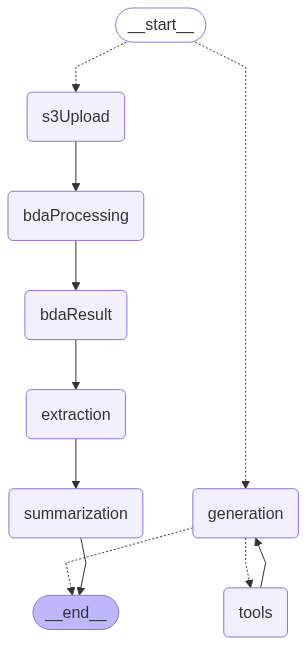

In [116]:
from IPython.display import Image as img, display

display(img(graph.get_graph().draw_mermaid_png()))


In [118]:
import json
session_id = "user-session-1"
config = {"configurable": {"thread_id": "1"}}

initial_state = {
    "document": None,
    "chat_history": [],
    "query": "",
    "response": "",
    "extracted_text": {},
    "bda_result":{},
    "s3Uri":{},
    "summary" : "",
    "question_list": [],

}

graph.update_state(config, values=initial_state, task_id=session_id)

def process_document(files):
    """Function to handle document upload and ingestion."""
    if files is None:
        return "Please upload a document first."
    file_bytes_list = {}
    # Read file bytes
    print(files)
    for file in files:
        file_bytes = ""
        with open(file.name, "rb") as f:
            file_bytes = f.read()
        file_bytes_list[os.path.basename(file.name)] = file_bytes

    current_state = graph.get_state(config)
    state_dict = dict(current_state.values)

    # Now you can modify it
    state_dict["document"] = file_bytes_list
    print(file_bytes_list.keys())
    # Invoke the graph with the updated dict
    text = graph.invoke(state_dict, config)
    # Persist updated state
    # graph.update_state(config, values=state_dict, task_id=session_id)
    print(text["question_list"])
    summary = text.get("summary", "No summary generated")
    questions = text.get("question_list", [])
    return summary, [[q] for q in questions]
    # Assuming the graph node returns extracted text or some processed response
    # return True

# def chat_interface(query, history):
#     """Function to handle user chat messages."""

#     current_state = graph.get_state(config)
    
#     state_dict = dict(current_state.values)

#     # Now you can modify it
#     state_dict["query"] = query
    
#     graph_state = graph.invoke(state_dict, config)

#     # graph.update_state(config, values=graph_state, task_id=session_id)
    
#     # Extract the AIMessage object from the "response" key
#     ai_message = graph_state.get("response")
#     print(ai_message)
    

#     if hasattr(ai_message, "content"):
#         bot_reply = ai_message.content
#     elif isinstance(ai_message, dict) and "content" in ai_message:
#         bot_reply = ai_message["content"]
#     else:
#         bot_reply = str(ai_message)

#     return history + [[query, bot_reply]]


# --- Chat Handler ---
def chat_interface(query, history):
    """Handle user chat messages with text + images using messages format."""
    if history is None:
        history = []

    # get & update state
    current_state = graph.get_state(config)
    state_dict = dict(current_state.values)
    state_dict["query"] = query

    # model response
    graph_state = graph.invoke(state_dict, config)
    ai_message = graph_state.get("response")
    print("Raw AI message:", ai_message, type(ai_message))
    print("---------------------------___________________------------------------")
    print(state_dict["messages"])
    print("---------------------------___________________------------------------")
    # --- normalize to Python types ---
    if hasattr(ai_message, "model_dump"):       # pydantic v2
        ai_message = ai_message.model_dump()
    elif hasattr(ai_message, "dict"):           # pydantic v1
        ai_message = ai_message.dict()
    elif isinstance(ai_message, str):
        try:
            ai_message = json.loads(ai_message)  # stringified JSON
        except Exception:
            # fallback: just show raw text
            history = history + [{"role": "user", "content": query},
                                 {"role": "assistant", "content": ai_message}]
            return history

    # ensure list-of-dicts shape like your example
    if isinstance(ai_message, dict):
        ai_message = [ai_message]
    if not isinstance(ai_message, list) or not ai_message:
        # absolute fallback
        history = history + [{"role": "user", "content": query},
                             {"role": "assistant", "content": str(ai_message)}]
        return history

    payload = ai_message[0] or {}
    text_msg = payload.get("text_message")
    image_urls = payload.get("image_urls") or []

    # --- build messages (messages format) ---
    # 1) append the user turn
    history = history + [{"role": "user", "content": query}]

    # 2) assistant text (if any)
    if text_msg:
        history.append({"role": "assistant", "content": str(text_msg)})

    # 3) assistant images (each image as its own message)
    # Use gr.Image component (doc-supported for messages content)
    for url in image_urls:
        history.append({
            "role": "assistant",
            "content": gr.Image(value=str(url), show_label=False)
        })

    return history



current_state_snapshot = graph.get_state(config)
current_state = current_state_snapshot.values
# show_question = False
# if len(current_state["question_list"]) > 0:
#     show_question = True
with gr.Blocks(title="Document Processing Agent",css=".btn {height : 60px;}") as demo:
    gr.Markdown("# LangGraph Document Agent")
    with gr.Row():
        with gr.Column(scale=1):
            file_upload = gr.File(label="Upload Documents", file_count="multiple")
            process_button = gr.Button("Process Document", variant="primary")
            ingestion_output = gr.Textbox(label="Document Processing Status And Summary", value=current_state['summary'])

        with gr.Column(scale=2):
            chatbot = gr.Chatbot(label="Chat with Agent", type="messages")
            with gr.Row():
                user_input = gr.Textbox(scale=8, show_label=False, submit_btn=True, placeholder="")
                # send_button = gr.Button("Send", scale=2, variant="primary", elem_classes="btn")

            # Use Dataset instead of Examples
            suggested_examples = gr.Dataset(
                # visible=show_question,
                label="Suggested Questions",
                headers=["Suggested Questions"],
                components=[gr.Textbox(visible=False)],
                samples= [[q] for q in current_state['question_list']]
            )

    # --- Wire events ---
    def process_and_update(files):
        summary, questions = process_document(files)
        return summary, gr.update(samples=questions)

    process_button.click(
        fn=process_and_update,
        inputs=file_upload,
        outputs=[ingestion_output, suggested_examples]
    )

    # Clicking dataset row autofills textbox
    def load_example(row):
        return row[0]

    suggested_examples.select(fn=load_example, inputs=[suggested_examples], outputs=[user_input])

    # send_button.click(fn=chat_interface, inputs=[user_input, chatbot], outputs=chatbot)
    user_input.submit(fn=chat_interface, inputs=[user_input, chatbot], outputs=chatbot)

demo.launch()


* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


['C:\\Users\\PratikTalaviya\\AppData\\Local\\Temp\\gradio\\492db7d24e468eea05a470c9f8555d108a73483c41983a24f1c0b742ce57c94a\\144255Compliance Pack.pdf', 'C:\\Users\\PratikTalaviya\\AppData\\Local\\Temp\\gradio\\bbc58a8d988d78e29ae9e230441a658d347d25c67f482feb202fbaaac9109b87\\144255BILL OF SALE.pdf', 'C:\\Users\\PratikTalaviya\\AppData\\Local\\Temp\\gradio\\48fb7fdfa52d058538aef321fc513a1991d01d59aaf921cf679700511a29c342\\144255GA MV-12020.pdf', 'C:\\Users\\PratikTalaviya\\AppData\\Local\\Temp\\gradio\\3d13902c3b605f06329d6d56ce63e8a9ab2864d553a2b3d0f8a8141a0f96e1ca\\144255Store Pack.pdf']
dict_keys(['144255Compliance Pack.pdf', '144255BILL OF SALE.pdf', '144255GA MV-12020.pdf', '144255Store Pack.pdf'])
{'chat_history': [], 'query': '', 'response': '', 'document': {'144255Compliance Pack.pdf': b'%PDF-1.7\n\n4 0 obj\n<<\n/BitsPerComponent 8\n/ColorSpace /DeviceRGB\n/Filter /DCTDecode\n/Height 267\n/Length 36999\n/Subtype /Image\n/Type /XObject\n/Width 414\n>>\nstream\n\xff\xd8\xff\xe0\x